## Objective¶
The objective of the Assignment is to analyse the leading cause of death in the developed world that is heart disease.

Therefore there needs to be work done to help prevent the risks of having a heart attack or stroke.

We use this dataset to predict which patients are most likely to suffer from a heart disease in the near future using the features given.

The resources for this dataset is the link: https://drive.google.com/file/d/1vkJC36xZJ9oaCLp1Q1Sp3ctXgqaxyQzN/view?usp=sharing

## 1. Import Libraries/Dataset 



In [3]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn import linear_model, tree, ensemble

## 2. Data Visualization and Exploration
2.1. Print 2 rows for sanity check to identify all the features present in the dataset and if the target matches with them.

In [4]:
all_df = pd.read_csv("Rawdata/heart.csv")

all_df.head(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0


<b> 2.2. Comment on class imbalance with appropriate visualization method. </b>

From the below cells(counts and countplot), we can infer that, the target feature is not imbalanced as the count of number of rows with different target values are almost same(526 and 499 i.e ratio is 1.0541 only.) Technically the dataset is not imbalanced as long as this ratio value is less than two. As our dataset is already balanced, we can move to the next step without taking any actions to make it balanced.

In [5]:
all_df['target'].value_counts() 

target
1    526
0    499
Name: count, dtype: int64

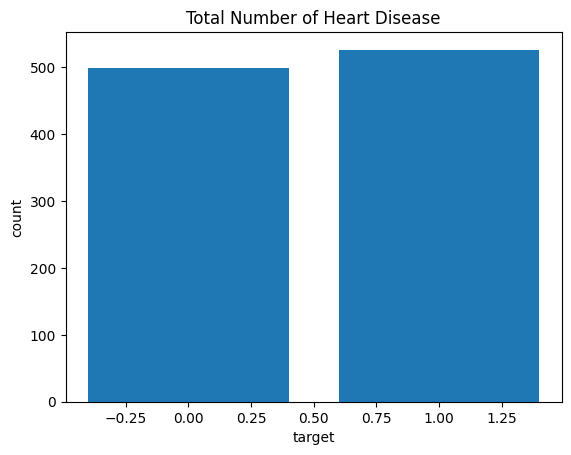

<Figure size 640x480 with 0 Axes>

In [6]:
# plt.figure(figsize=(18,9))
unique_counts = all_df['target'].value_counts() 

# Rename the columns
count_df = unique_counts.reset_index()
count_df.columns = ['Value','Count']

plt.bar(count_df['Value'],count_df['Count'])
plt.title('Total Number of Heart Disease')
plt.xlabel('target')
plt.ylabel('count')
plt.show()
plt.tight_layout()

 2.3. Provide appropriate data visualizations to get an insight about the dataset.

Age Analysis : Analysis of the individual features which comprises both univariate and bivariate analysis

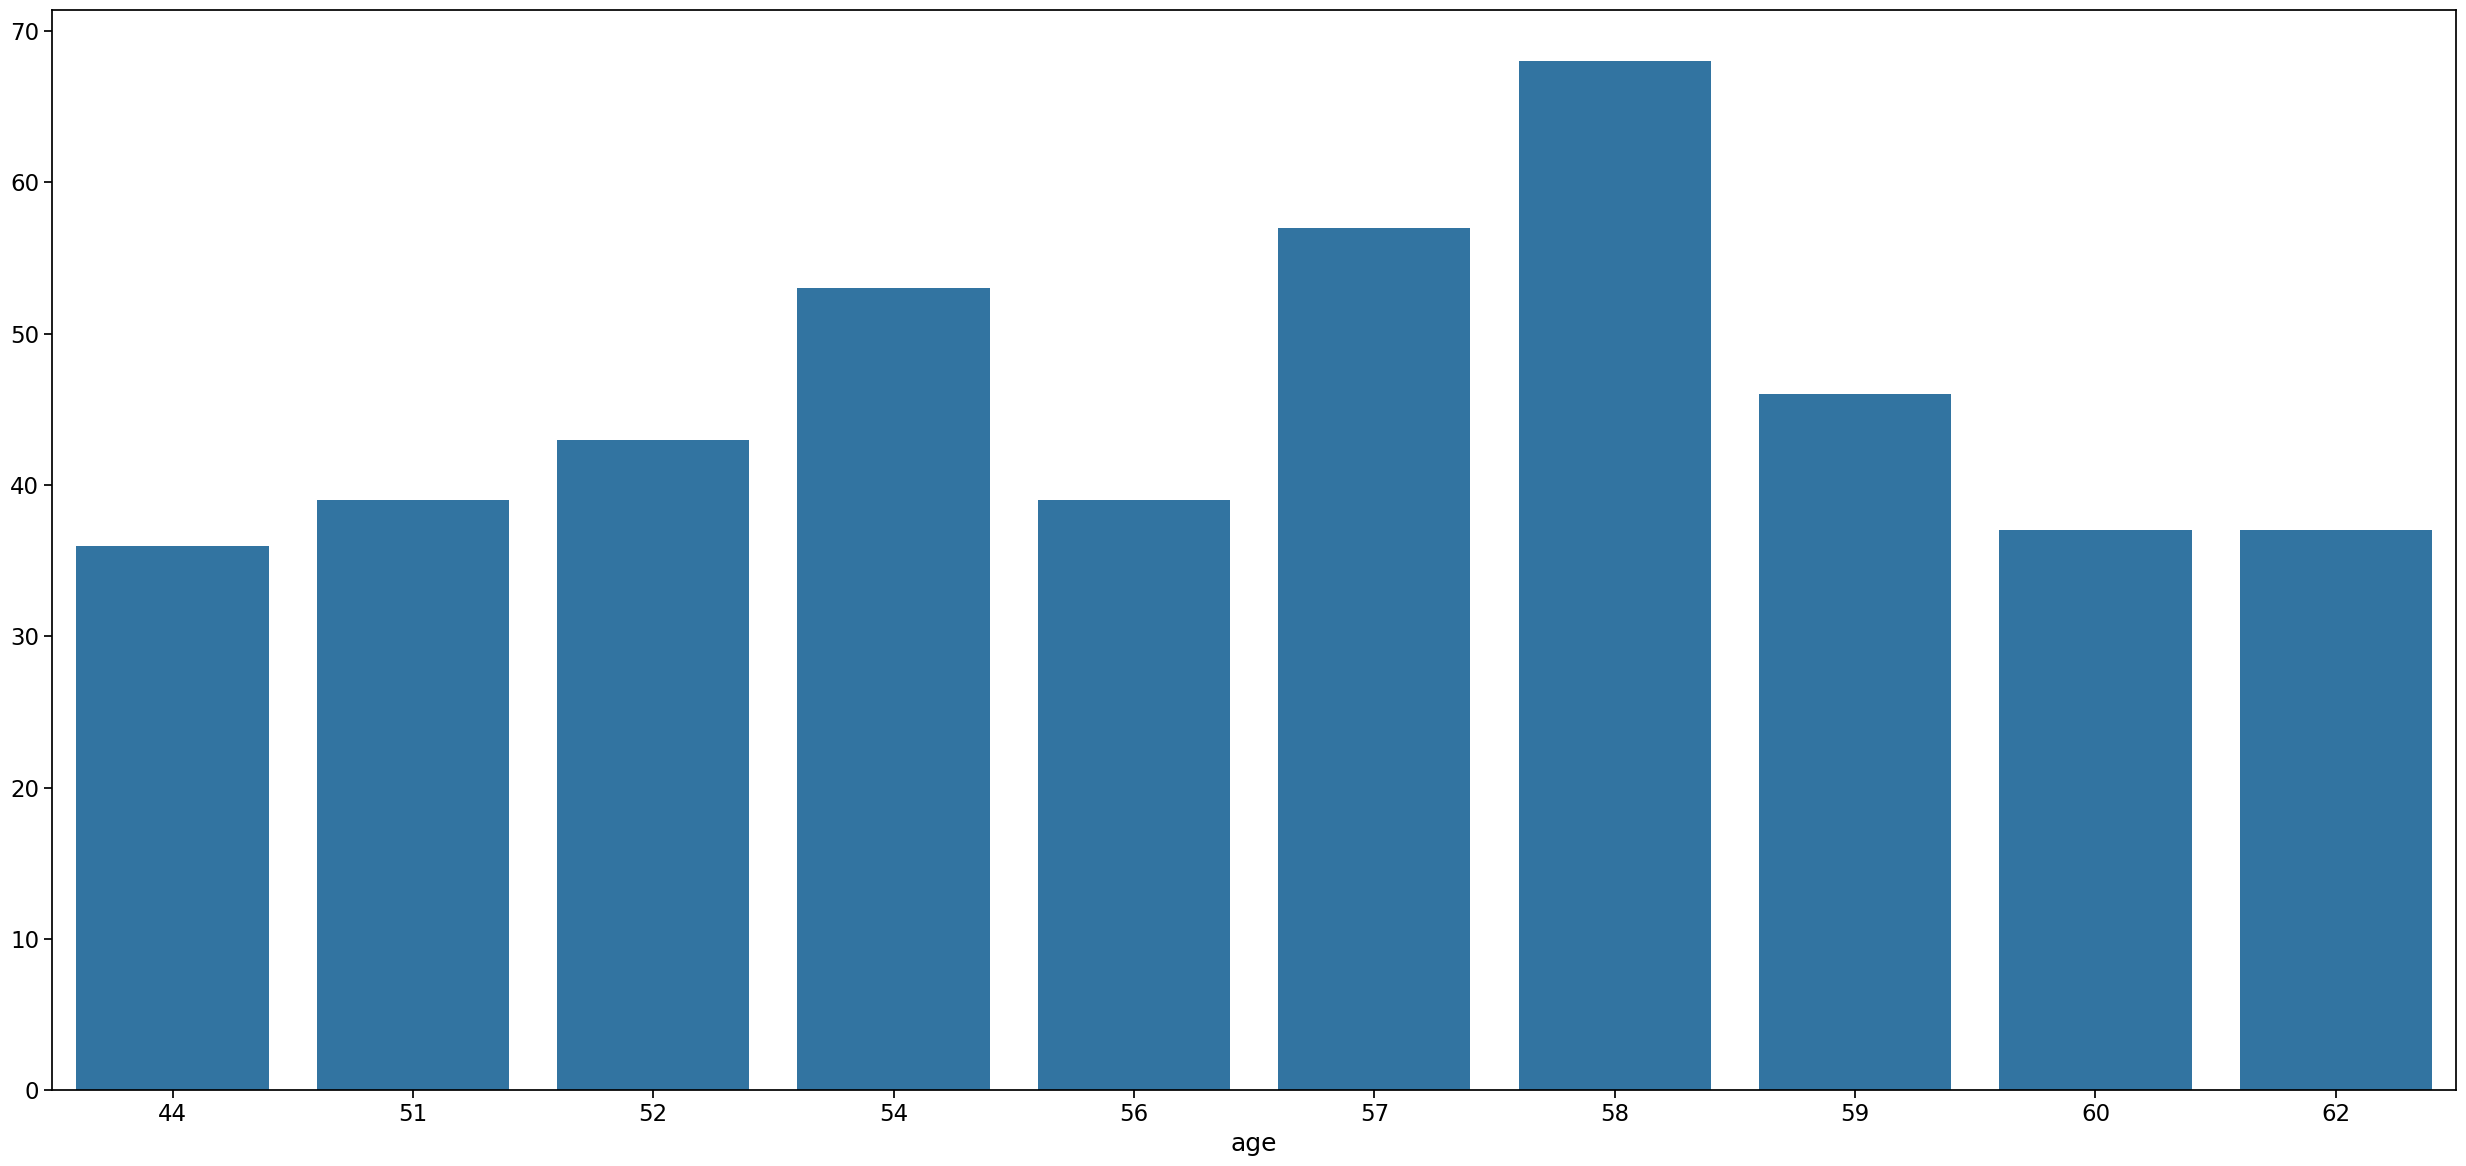

In [7]:
plt.figure(figsize=(25,12))
sns.set_context('notebook',font_scale = 1.5)
sns.barplot(x=all_df.age.value_counts()[:10].index,y=all_df.age.value_counts()[:10].values)
plt.tight_layout()

In [8]:
#check the range in the dataset
minAge=min(all_df.age)
maxAge=max(all_df.age)
meanAge=all_df.age.mean()
print('Min Age :',minAge)
print('Max Age :',maxAge)
print('Mean Age :',meanAge)

Min Age : 29
Max Age : 77
Mean Age : 54.43414634146342


Age group is between 44 and 62 that is categorised as young and elders that is based on the mean value of the age calculated to be 54 years.

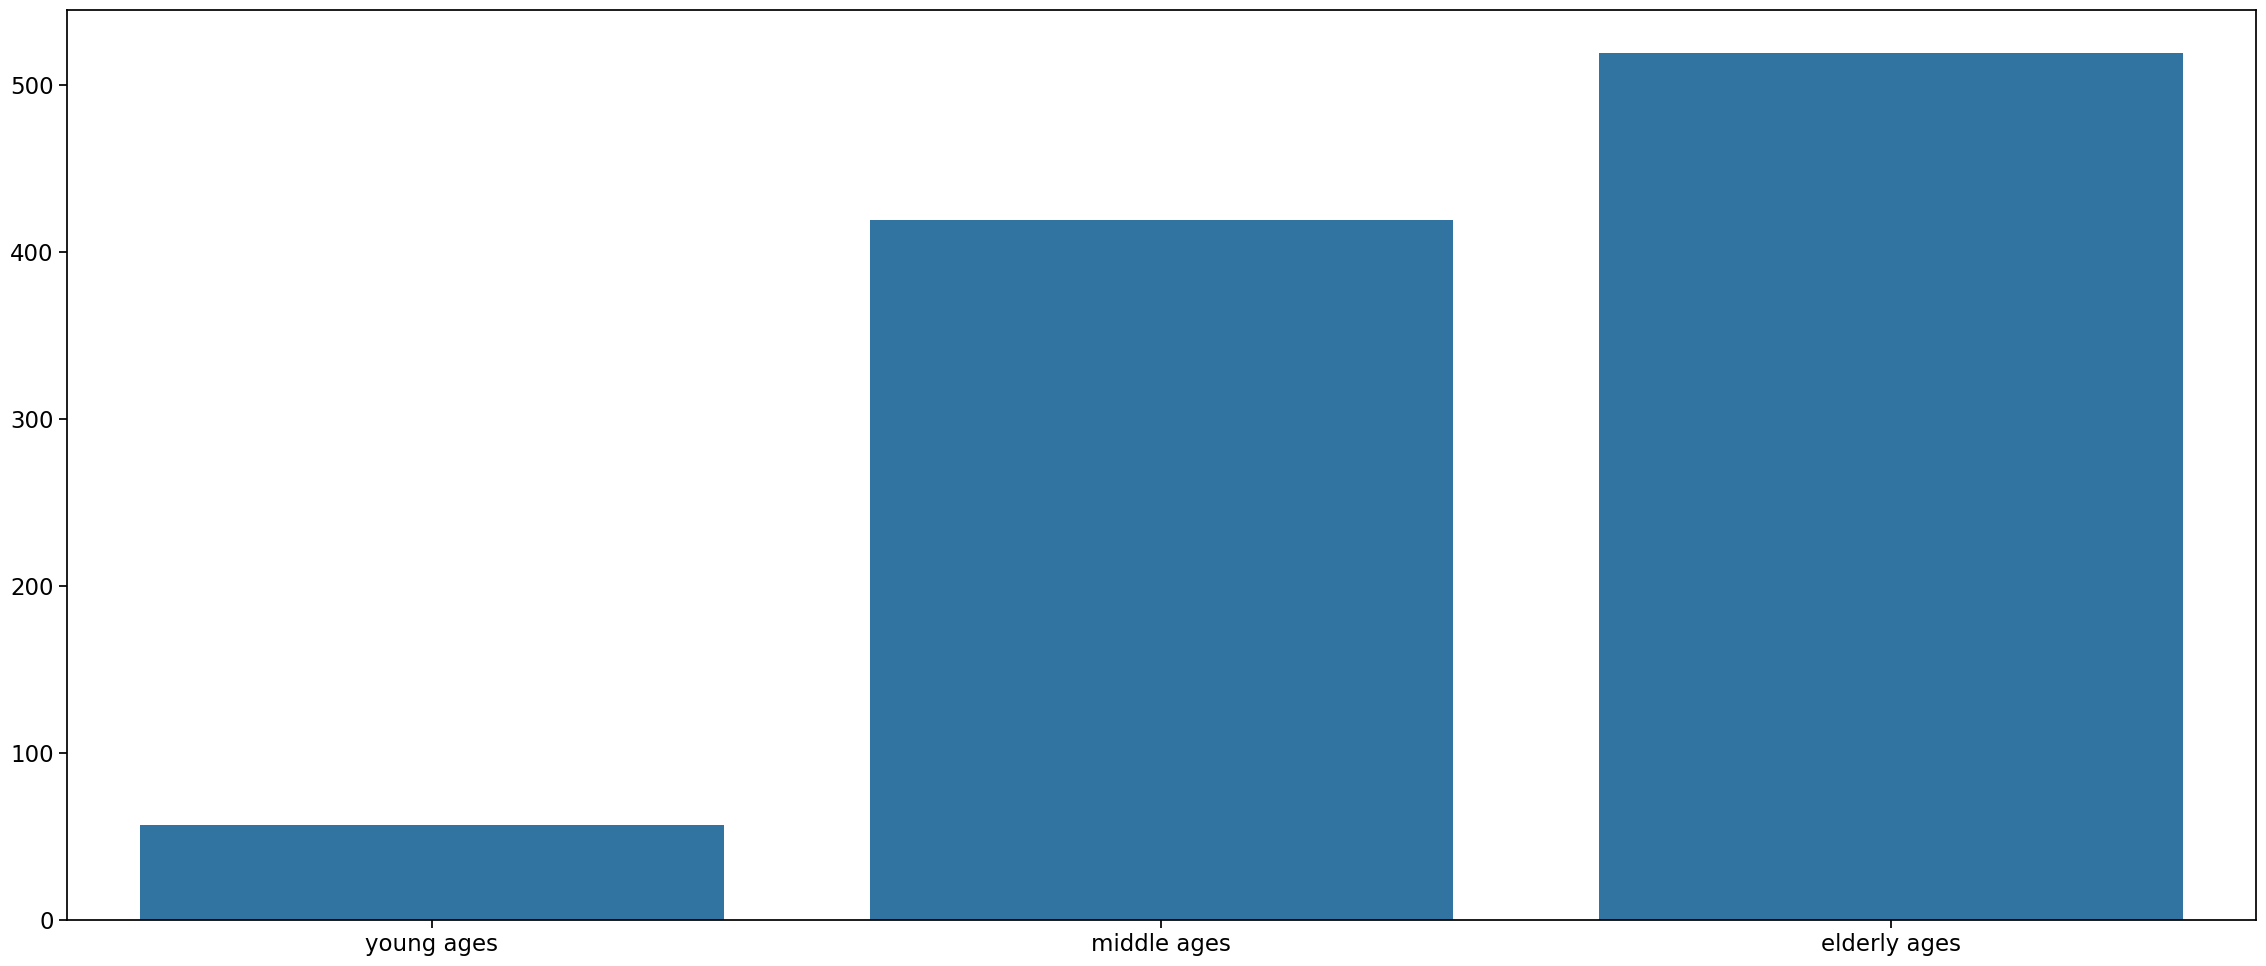

In [9]:
Young = all_df[(all_df.age>=29)&(all_df.age<40)]
Middle = all_df[(all_df.age>=40)&(all_df.age<55)]
Elder = all_df[(all_df.age>55)]

plt.figure(figsize=(23,10))
sns.set_context('notebook',font_scale = 1.5)
sns.barplot(x=['young ages','middle ages','elderly ages'],y=[len(Young),len(Middle),len(Elder)])
plt.tight_layout()

From the above chart we can observe that elderly are most affected with heart disease and younger ones are least affected by heart disease.

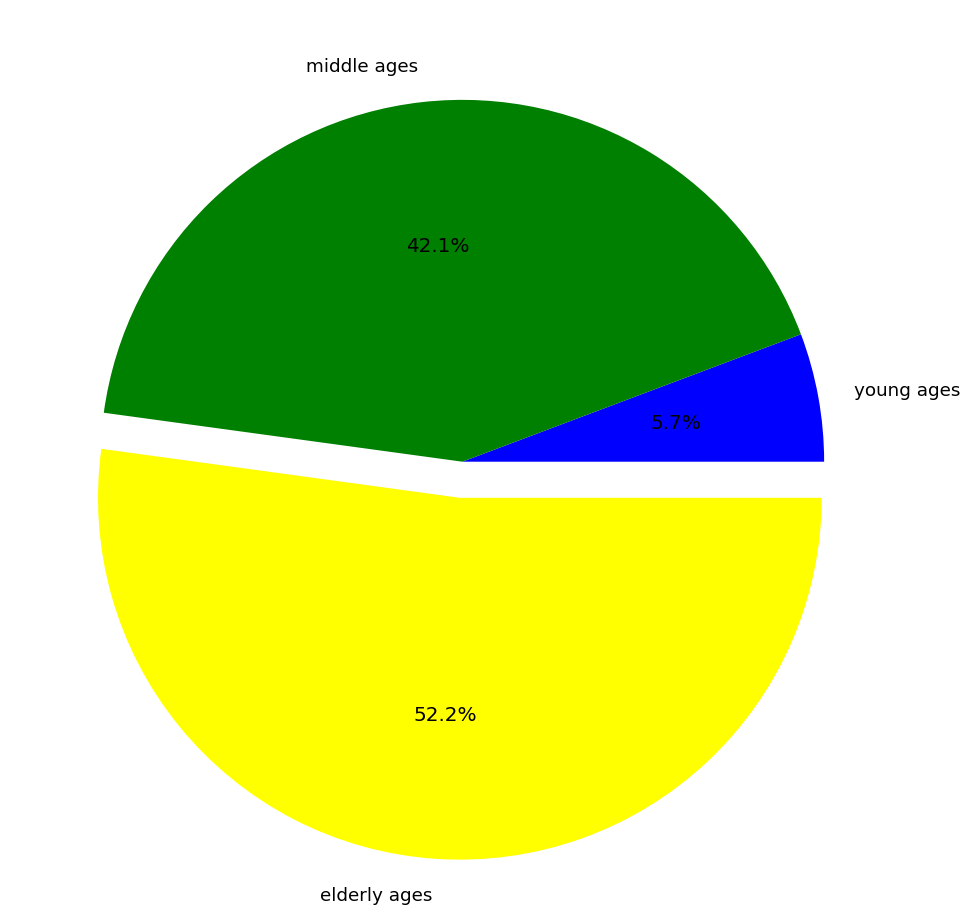

In [10]:
colors = ['blue','green','yellow']
explode = [0,0,0.1]
plt.figure(figsize=(10,10))
sns.set_context('notebook',font_scale = 1.2)
plt.pie([len(Young),len(Middle),len(Elder)],labels=['young ages','middle ages','elderly ages'],explode=explode,colors=colors, autopct='%1.1f%%')
plt.tight_layout()

## 2.4. Do the correlational analysis on the dataset.
Provide a visualization for the same.
Will this correlational analysis have effect on feature selection that you will perform in the next step?
Justify your answer.

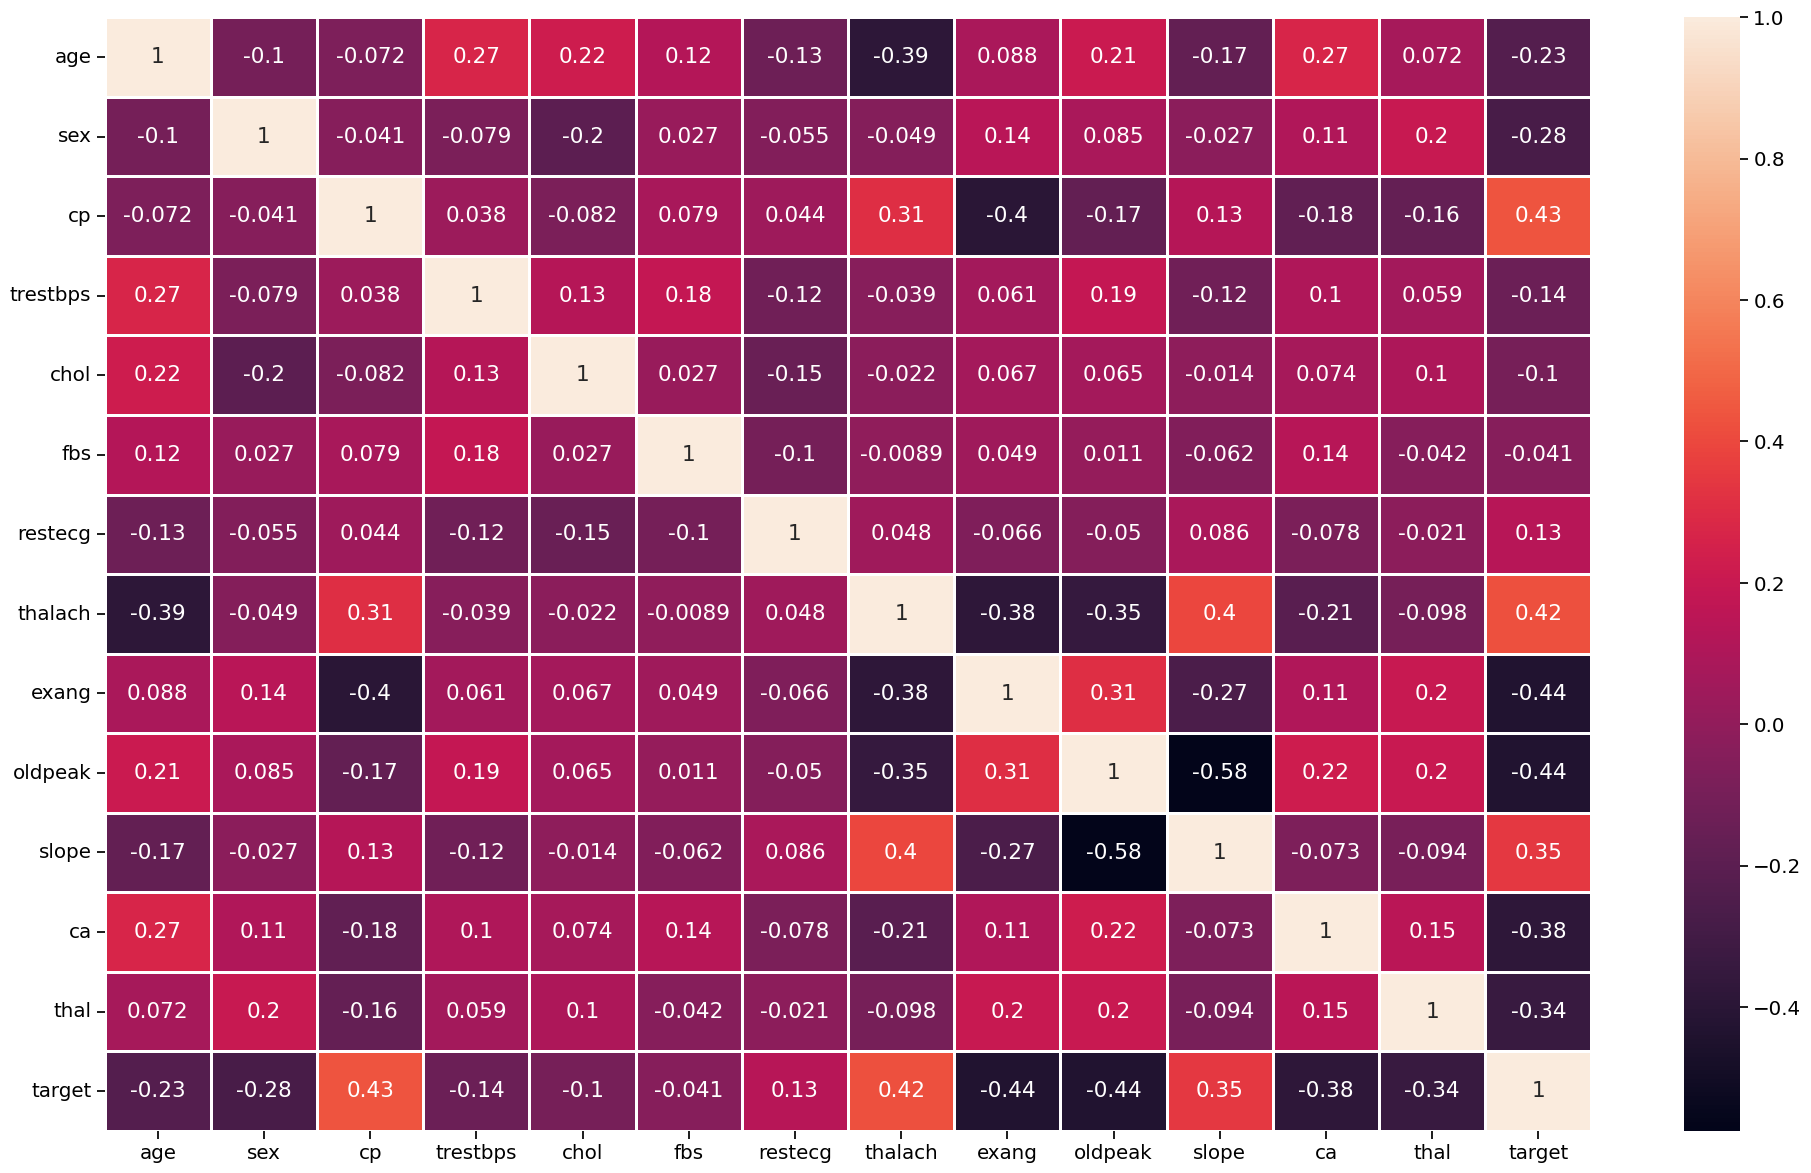

In [11]:
#Correlation between the features
plt.figure(figsize=(20,12))
sns.set_context('notebook',font_scale = 1.3)
sns.heatmap(all_df.corr(),annot=True,linewidth =2)
plt.tight_layout()

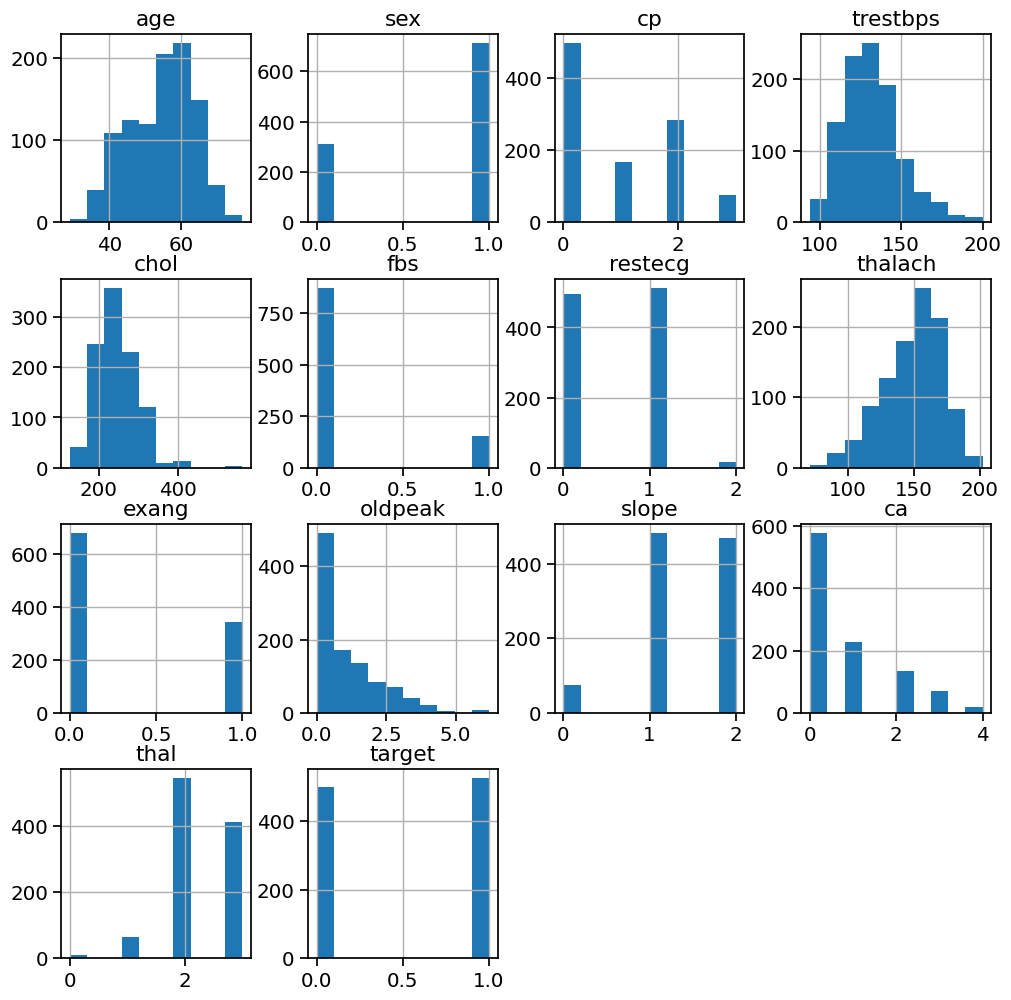

In [12]:
all_df.hist(figsize=(12,12))
plt.savefig("featuresplot")

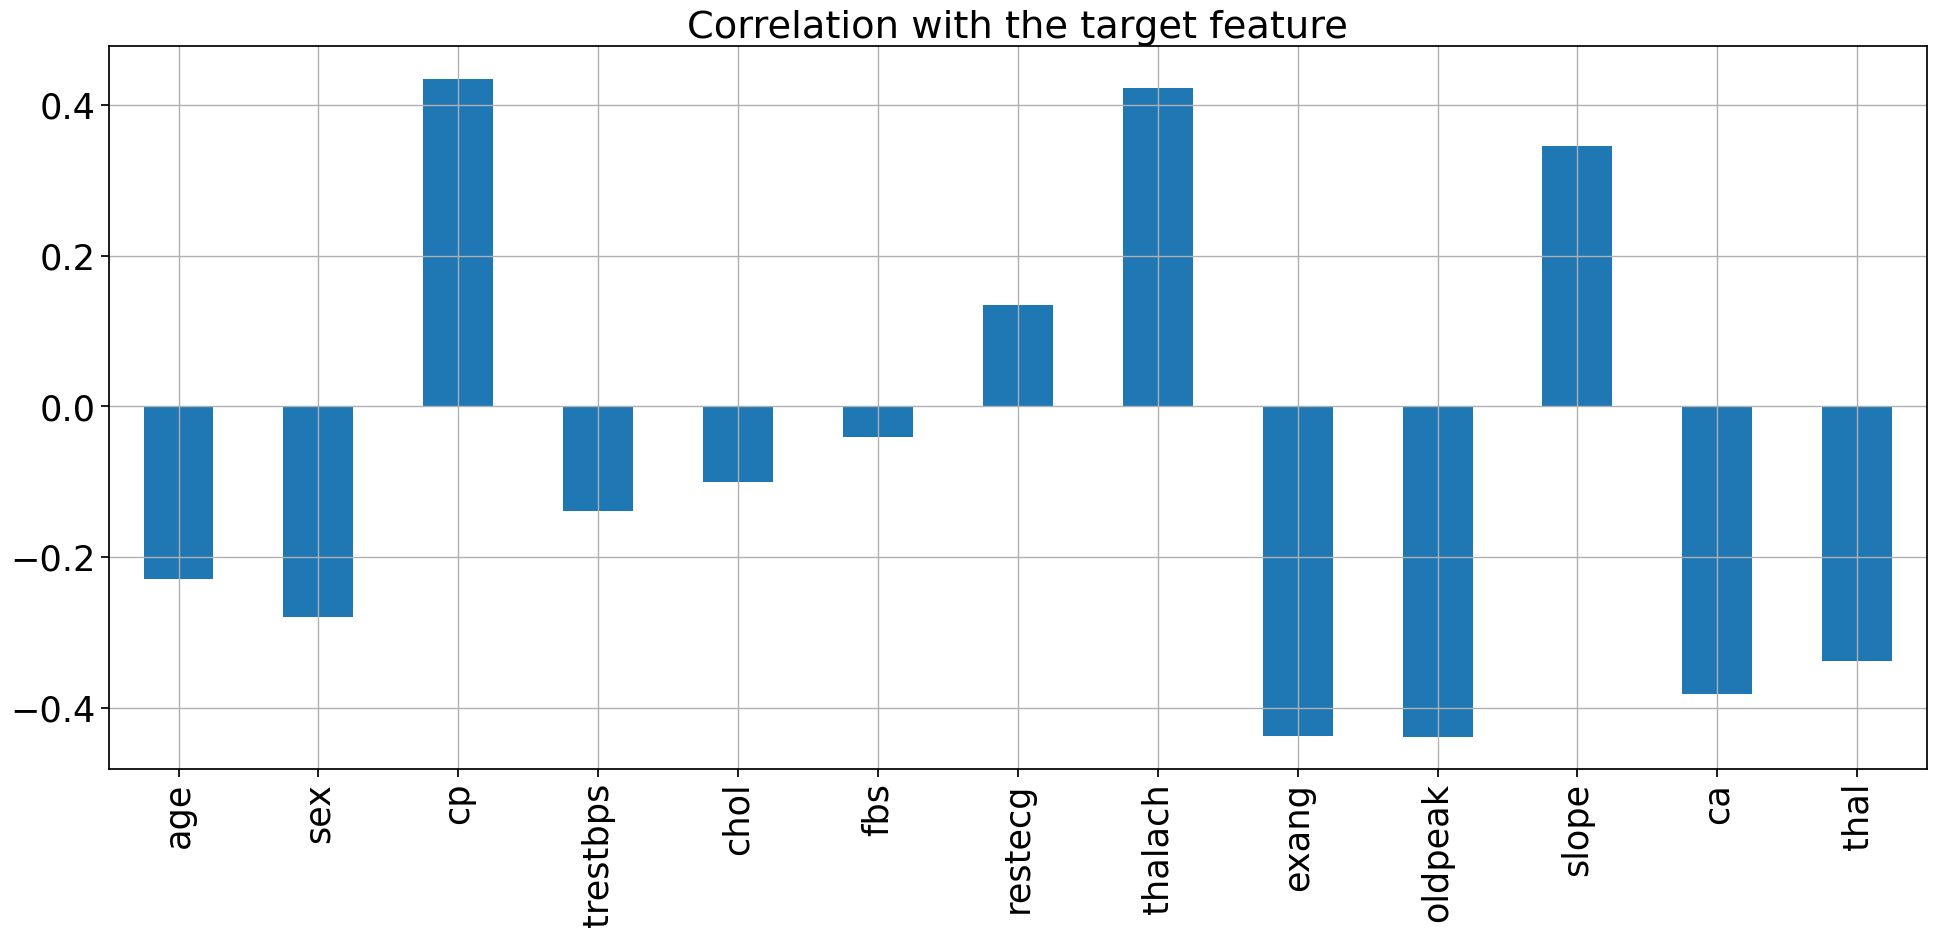

In [13]:
#correlation with the target variable
sns.set_context('notebook',font_scale = 2.3)
all_df.drop('target', axis=1).corrwith(all_df.target).plot(kind='bar', grid=True, figsize=(20, 10), 
                                                        title="Correlation with the target feature")
plt.tight_layout()

From the above Bar Chart we can infer, 4 fetures are positively correalted with the target feature

Four feature( “cp”, “restecg”, “thalach”, “slope” ) are positively correlated with the target feature.

Other features are negatively correlated with the target feature.

<h3>3.	Data Pre-processing and cleaning </h3>
<b>3.1.	Do the appropriate pre-processing of the data like identifying NULL or Missing Values if any, handling of outliers if present in the dataset, skewed data etc.Mention the pre-processing steps performed in the markdown cell with justification.</b>
    <p> Null values were checked and removed.

<b>3.2.	Apply appropriate feature engineering techniques for them.     
    Apply the feature transformation techniques like Standardization, Normalization, etc.     
    You are free to apply the appropriate transformations depending upon the structure and the complexity of your dataset.    
    Provide proper justification</b>
    <p> The continuous and categorical features are identified and transformed appropriately. For example Age which was a continuous feature was transformed and scaled into a categorical value of 3 categories.</p>



In [14]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [15]:
all_df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [16]:
all_df.shape

(1025, 14)

In [17]:
all_df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [18]:
#Feature Engineering 

categorical_val = []
continous_val = []
for column in all_df.columns:
    print("--------------------")
    print(f"{column} : {all_df[column].unique()}")
    if len(all_df[column].unique()) <= 10:
        categorical_val.append(column)
    else:
        continous_val.append(column)

--------------------
age : [52 53 70 61 62 58 55 46 54 71 43 34 51 50 60 67 45 63 42 44 56 57 59 64
 65 41 66 38 49 48 29 37 47 68 76 40 39 77 69 35 74]
--------------------
sex : [1 0]
--------------------
cp : [0 1 2 3]
--------------------
trestbps : [125 140 145 148 138 100 114 160 120 122 112 132 118 128 124 106 104 135
 130 136 180 129 150 178 146 117 152 154 170 134 174 144 108 123 110 142
 126 192 115  94 200 165 102 105 155 172 164 156 101]
--------------------
chol : [212 203 174 294 248 318 289 249 286 149 341 210 298 204 308 266 244 211
 185 223 208 252 209 307 233 319 256 327 169 131 269 196 231 213 271 263
 229 360 258 330 342 226 228 278 230 283 241 175 188 217 193 245 232 299
 288 197 315 215 164 326 207 177 257 255 187 201 220 268 267 236 303 282
 126 309 186 275 281 206 335 218 254 295 417 260 240 302 192 225 325 235
 274 234 182 167 172 321 300 199 564 157 304 222 184 354 160 247 239 246
 409 293 180 250 221 200 227 243 311 261 242 205 306 219 353 198 394 183
 237 22

In [19]:
categorical_val.remove('target')
dfs = pd.get_dummies(all_df, columns = categorical_val)
dfs.head(6)

,age,trestbps,chol,thalach,oldpeak,target,sex_0,sex_1,cp_0,cp_1,...,slope_2,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3
0,52,125,212,168,1.0,0,False,True,True,False,...,True,False,False,True,False,False,False,False,False,True
1,53,140,203,155,3.1,0,False,True,True,False,...,False,True,False,False,False,False,False,False,False,True
2,70,145,174,125,2.6,0,False,True,True,False,...,False,True,False,False,False,False,False,False,False,True
3,61,148,203,161,0.0,0,False,True,True,False,...,True,False,True,False,False,False,False,False,False,True
4,62,138,294,106,1.9,0,True,False,True,False,...,False,False,False,False,True,False,False,False,True,False
5,58,100,248,122,1.0,1,True,False,True,False,...,False,True,False,False,False,False,False,False,True,False


In [20]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
col_to_scale = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
dfs[col_to_scale] = sc.fit_transform(dfs[col_to_scale])
dfs.head(6)

,age,trestbps,chol,thalach,oldpeak,target,sex_0,sex_1,cp_0,cp_1,...,slope_2,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3
0,-0.268437,-0.377636,-0.659332,0.821321,-0.060888,0,False,True,True,False,...,True,False,False,True,False,False,False,False,False,True
1,-0.158157,0.479107,-0.833861,0.255968,1.727137,0,False,True,True,False,...,False,True,False,False,False,False,False,False,False,True
2,1.716595,0.764688,-1.396233,-1.048692,1.301417,0,False,True,True,False,...,False,True,False,False,False,False,False,False,False,True
3,0.724079,0.936037,-0.833861,0.516900,-0.912329,0,False,True,True,False,...,True,False,True,False,False,False,False,False,False,True
4,0.834359,0.364875,0.930822,-1.874977,0.705408,0,True,False,True,False,...,False,False,False,False,True,False,False,False,True,False
5,0.393241,-1.805540,0.038784,-1.179158,-0.060888,1,True,False,True,False,...,False,True,False,False,False,False,False,False,True,False



## Feature Analysis

In [25]:
sex_counts = all_df['sex'].value_counts()
sex_df = sex_counts.reset_index()
sex_df.columns = ['Value','Count']


Here we can see that there are 713 Males and 312 Females in the data set . <B> Ratio of Male to Female is 2:3 </B>

In [26]:
# relation between sex and slope
plt.figure(figsize=(18,9))
sns.set_context('notebook',font_scale = 1.5)

sns.countplot(all_df['sex'],hue=all_df["slope"])
plt.tight_layout()

ValueError: The following variable cannot be assigned with wide-form data: `hue`

<Figure size 1800x900 with 0 Axes>

<h3> Chest Pain ("cp") Analysis </h3>

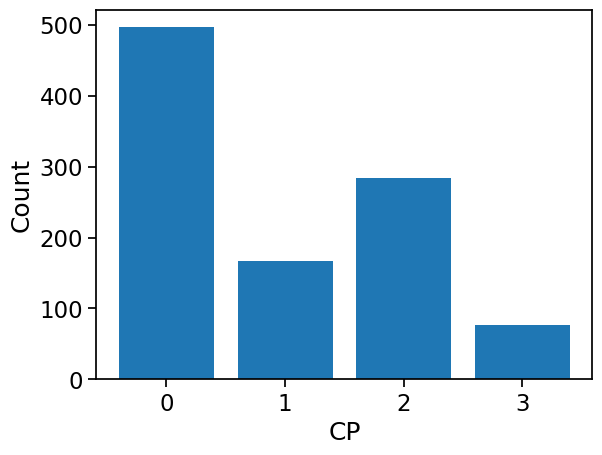

<Figure size 640x480 with 0 Axes>

In [24]:
cp_counts = all_df['cp'].value_counts() 

# Rename the columns
cp_df = cp_counts.reset_index()
cp_df.columns = ['Value','Count']

plt.bar(cp_df['Value'],cp_df['Count'])
plt.xlabel('CP')
plt.ylabel('Count')
plt.show()
plt.tight_layout()


# plt.figure(figsize=(18,9))
# sns.set_context('notebook',font_scale = 1.5)
# sns.countplot(all_df['cp'])
# plt.tight_layout()

From the above chart , we can say that

There are 4 types of chest pain
<B>
1) status at least   
2) condition slightly distressed   
3) condition medium problem   
4) condition too bad   

</B>

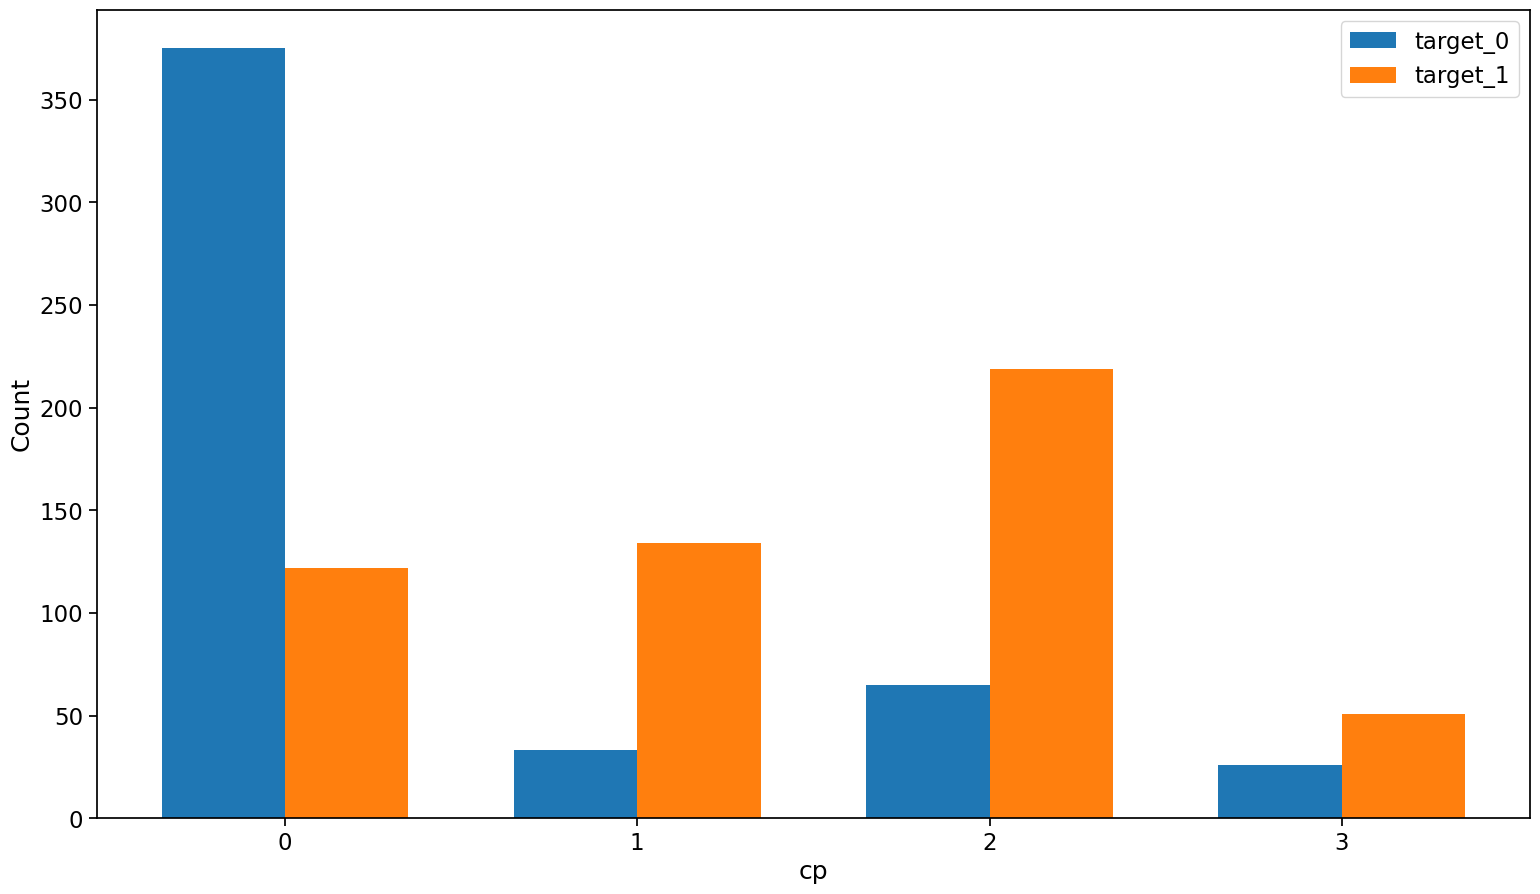

In [57]:
# relation between cp and target
cp_df1 = all_df.groupby(['cp','target'],as_index=False).sex.count()
# all_df.plot(x="cp", y=["target","sex"], kind="bar") 
cp_df1.columns = ['cp', 'target', 'count']
cp_df1 = cp_df1.pivot(index='cp', columns='target', values='count').reset_index()
cp_df1.columns = ['cp','target_0','target_1']

labels = cp_df1['cp']
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
target_0 = ax.bar(x - width/2, cp_df1['target_0'], width, label='target_0') # Add color here
target_1 = ax.bar(x + width/2, cp_df1['target_1'], width, label='target_1')

ax.set_xlabel('cp')
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(labels)
fig.set_size_inches(18.5, 10.5)
plt.rcParams.update({'font.size': 15})
ax.legend()

plt.show()
# cp_df1.plot(x=cp_df1['cp'], y=[cp_df1['target'], cp_df1['sex']], kind="bar") 

From the above graph we can infer that,

<B> People having the least chest pain are not likely to have heart disease. </B>

<B> People having severe chest pain are likely to have heart disease.  </B>

<B> Elderly people are more likely to have chest pain.</B>

<h3> THAL Analysis </h3>

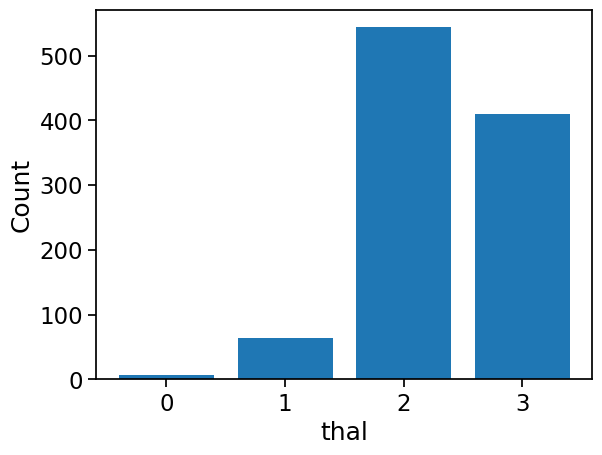

<Figure size 640x480 with 0 Axes>

In [61]:
thal_counts = all_df['thal'].value_counts() 

# Rename the columns
thal_df = thal_counts.reset_index()
thal_df.columns = ['Value','Count']

plt.bar(thal_df['Value'],thal_df['Count'])
plt.xlabel('thal')
plt.ylabel('Count')
plt.show()
plt.tight_layout()

<h3>4.	Model Building  </h3>

<b>4.1.	Split the dataset into training and test sets. Justify your choice of split. You may experiment with different split to get the final split.

The Splitting dataset into 75% training data and 25% test data was done in the above 

In [62]:
from sklearn.model_selection import  RandomizedSearchCV, train_test_split
X=dfs.drop('target',axis=1)
y=dfs.target

X_train,X_test,y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=40)

<b>4.2.	Build Model Development using KNN and Decision Tree. 

Accuracy is the most intuitive performance measure and it is simply a ratio of correctly predicted observation to the total observations. But when the cost of false positives and false negatives are very different(which is true in our case as falsely predicting to be heard disease negative is more dangerous than the opposite ), it’s better to look at F1 score also which is the weighted average of Precision and Recall. F1 score takes both false positives and false negatives into account.
As we can see from the above Confusion Matrices, it is evident that Decision Tree Classifier model outperforms KNN Classifier model in all the considerable metrics.

<B> Build Model Using KNN Algorithm </B>


the whole dataset splitted into trainset and testset which contains 75% training and 25% test.

We can include this train set into classifiers to train our model and the test set is useful for predicting the performance of the model by different classifier

              precision    recall  f1-score   support

           0       0.86      0.85      0.86       123
           1       0.87      0.87      0.87       134

    accuracy                           0.86       257
   macro avg       0.86      0.86      0.86       257
weighted avg       0.86      0.86      0.86       257

0.8638132295719845


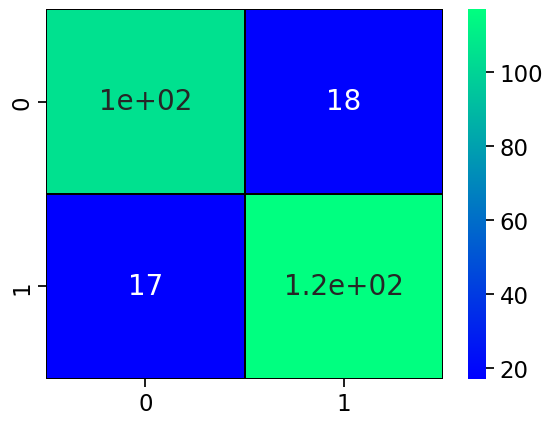

In [64]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 10)
knn.fit(X_train,y_train)
prediction=knn.predict(X_test)
cm= confusion_matrix(y_test,prediction)
sns.heatmap(cm, annot=True,cmap='winter',linewidths=0.3, linecolor='black',annot_kws={"size": 20})
print(classification_report(y_test, prediction))
y_pred1 = knn.predict(X_test)
print(accuracy_score(y_test,y_pred1))

<B> Build Model Using Decision Tree Algorithm </B>



              precision    recall  f1-score   support

           0       0.95      0.87      0.91       123
           1       0.89      0.96      0.92       134

    accuracy                           0.91       257
   macro avg       0.92      0.91      0.91       257
weighted avg       0.92      0.91      0.91       257

Testing Accuracy for Decision Tree: 0.914396887159533
Testing Sensitivity for Decision Tree: 0.9469026548672567
Testing Specificity for Decision Tree: 0.8888888888888888
Testing Precision for Decision Tree: 0.8699186991869918


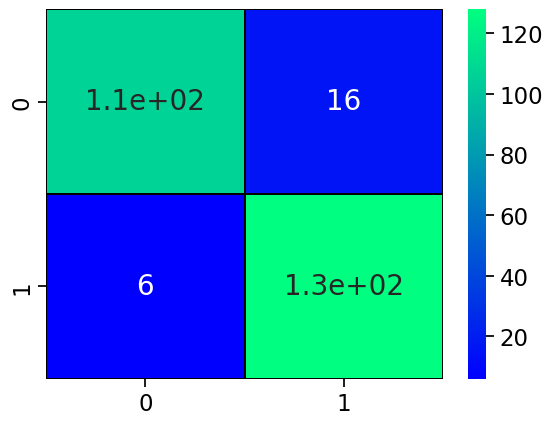

In [65]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn import linear_model, tree, ensemble


tree_model = DecisionTreeClassifier(max_depth=5,criterion='entropy')
cv_scores = cross_val_score(tree_model, X, y, cv=10, scoring='accuracy')
m=tree_model.fit(X, y)

prediction=m.predict(X_test)
cm= confusion_matrix(y_test,prediction)
sns.heatmap(cm, annot=True,cmap='winter',linewidths=0.3, linecolor='black',annot_kws={"size": 20})
print(classification_report(y_test, prediction))

TP=cm[0][0]
TN=cm[1][1]
FN=cm[1][0]
FP=cm[0][1]
print('Testing Accuracy for Decision Tree:',(TP+TN)/(TP+TN+FN+FP))
print('Testing Sensitivity for Decision Tree:',(TP/(TP+FN)))
print('Testing Specificity for Decision Tree:',(TN/(TN+FP)))
print('Testing Precision for Decision Tree:',(TP/(TP+FP)))

<h3>5.	Performance Evaluation </h3>

<h3> Final Model Implementation </h3>

In [66]:
from sklearn import metrics

def build_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    score = model.score(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(predictions, y_test)
    
    #Plotting ROC curve(True Positive Rate against False Positive Rate) of each model
    probs = model.predict_proba(X_test)
    preds = probs[:,1]
    fpr, tpr, threshold = metrics.roc_curve(y_test, preds)
    roc_auc = metrics.auc(fpr, tpr)

    plt.title('Receiver Operating Characteristic')
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    
    return (score, accuracy, predictions)



ROC curve of 'KNeighborsClassifier(ML1) ' 


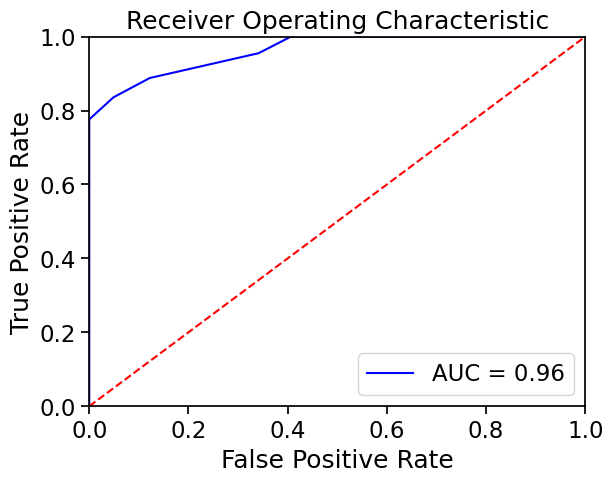



Classification Report of 'KNeighborsClassifier(ML1) '  
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       123
           1       0.89      0.89      0.89       134

    accuracy                           0.88       257
   macro avg       0.88      0.88      0.88       257
weighted avg       0.88      0.88      0.88       257



ROC curve of 'KNeighborsClassifier(ML1) ' using se columns (FE2) 



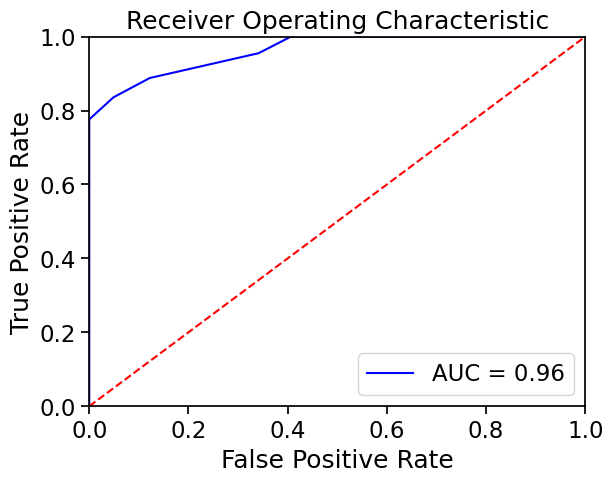



Classification Report of 'KNeighborsClassifier(ML1) ' 
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       123
           1       0.89      0.89      0.89       134

    accuracy                           0.88       257
   macro avg       0.88      0.88      0.88       257
weighted avg       0.88      0.88      0.88       257



ROC curve of 'DecisionTreeClassifier(ML2) ' 


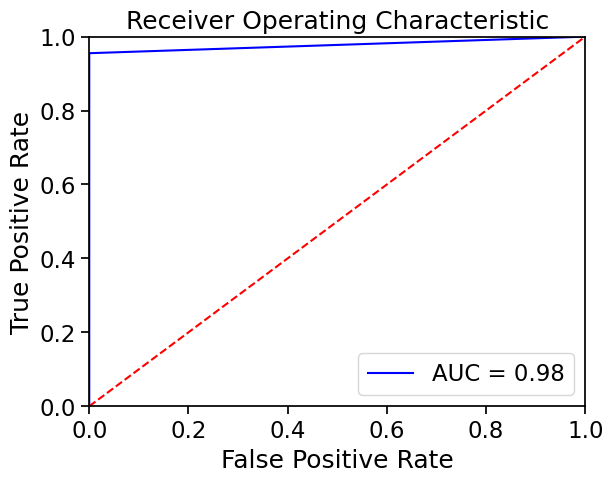



Classification Report of 'DecisionTreeClassifier(ML2) '  
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       123
           1       1.00      0.96      0.98       134

    accuracy                           0.98       257
   macro avg       0.98      0.98      0.98       257
weighted avg       0.98      0.98      0.98       257



ROC curve of 'DecisionTreeClassifier(ML2) ' using se columns (FE2) 



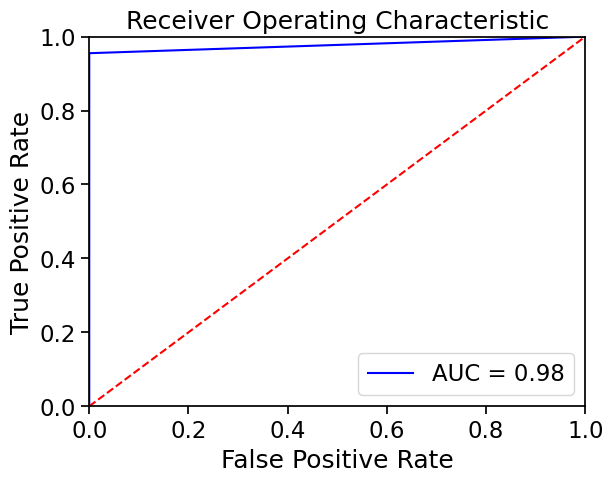



Classification Report of 'DecisionTreeClassifier(ML2) ' 
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       123
           1       1.00      0.96      0.98       134

    accuracy                           0.98       257
   macro avg       0.98      0.98      0.98       257
weighted avg       0.98      0.98      0.98       257



In [67]:
# importing Machine Learning Techniques
from sklearn.neighbors import KNeighborsClassifier # ML Technique 1
from sklearn.tree import DecisionTreeClassifier     # ML Technique 2

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, confusion_matrix

confusion_matrices = []
dataframe_prediction = []
dataframe_prediction_columns = [ 'model_name', 'score', 'accuracy_score' , "accuracy_percentage"]

for name, model in zip(list(['KNeighborsClassifier(ML1)', 'DecisionTreeClassifier(ML2)']), list([KNeighborsClassifier(), DecisionTreeClassifier(criterion='entropy', random_state=0)])):
    
    print("\n\nROC curve of '"+ str(name), "' ")
    
    (score, accuracy, predictions) = build_model(model, X_train, X_test, y_train, y_test )
    
    print("\n\nClassification Report of '"+ str(name), "'  ")
    
    print(classification_report(y_test, predictions))

    dataframe_prediction.append([name, score, accuracy, "{0:.2%}".format(accuracy)])
    
    # For Showing Matrices
    confusion_matrices.append(confusion_matrix(y_test, predictions))
    
    print("\n\nROC curve of '"+ str(name), "' using se columns (FE2) \n")
    
    (score, accuracy, predictions) = build_model(model, X_train, X_test, y_train, y_test )
    
    print("\n\nClassification Report of '"+ str(name), "' ")
    
    print(classification_report(y_test, predictions))

    dataframe_prediction.append([name, score, accuracy, "{0:.2%}".format(accuracy)])
    
    # For Showing Matrices
    confusion_matrices.append(confusion_matrix(y_test, predictions))
    
        
dataframe_pred = pd.DataFrame(dataframe_prediction, columns=dataframe_prediction_columns)

In [68]:
dataframe_pred

,model_name,score,accuracy_score,accuracy_percentage
0,KNeighborsClassifier(ML1),0.960938,0.883268,88.33%
1,KNeighborsClassifier(ML1),0.960938,0.883268,88.33%
2,DecisionTreeClassifier(ML2),1.000000,0.976654,97.67%
3,DecisionTreeClassifier(ML2),1.000000,0.976654,97.67%


From this prediction we can infer than Decision tree classifier model has 97% accuracy Hence Decision tree classifier is better than the KNeighborsClassifier

<B> 5.1.	Do the prediction for the test data and display the results for the inference.     
    Calculate all the evaluation metrics and choose best for your model.      
    Justify your answer.</B>
    
<p> If the heart disease is predicted as negative and the heart patient with heart disease will be considered as wrong prediction causing severe condition to the person. 
Hence based on the accuracy percentage we are able to mark the patient with positive cases of heart disease by predicting based on the above metrics. It is better to look at F1 score also which is the weighted average of Precision and Recall. F1 score takes both false positives and false negatives into account. As we can see from the above Confusion Matrices, it is evident that Decision Tree Classifier model outperforms KNN Classifier model in all the considerable metrics.</p>

<b>5.2.	Compare the model in tabulated form. </b>
<p> Comparing the accuracy, Sensitivity, Specificity, Precision for both the Build Models KNN Algorithm and Decision Tree we find that Decision Tree Classifier model outperforms KNN Classifier model in all the considerable metrics.</p>

Reference : https://www.analyticsvidhya.com/blog/2022/02/heart-disease-prediction-using-machine-learning/